In [2]:
from util import go_to_project_root
go_to_project_root()

CWD changed to the project root: /home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1


# Pregunta 1

In [5]:
import numpy as np
import matplotlib.pyplot as plt 

from source.models.autoregressive import AR
from source.utils.plot import plot_irf_comparison, save_figure

%load_ext autoreload
%autoreload 2

El proceso AR(p) viene definido por: 

$$y_t = c + \phi_{1}y_{t-1} + ...  + \phi_py{t-p} + u_t$$

In [41]:
fixed_phi = [0.5, 0.5]

In [43]:
ar_model = AR(params_distribution='stationary', p=5, c=2)
print(ar_model)

               AR(5) Model Summary                
Model Order (p)          : 5
Intercept (c)            : 2
Error Std Dev (sigma)    : 1.0
Is Stationary            : True
Mu (Unc. Mean):          : 0.25
Max Eigenvalue Modulus   : 0.9459
--------------------------------------------------
Coefficients (phi):
  phi_1    =    -2.1687
  phi_2    =    -2.5260
  phi_3    =    -1.6705
  phi_4    =    -0.6073
  phi_5    =    -0.1695


In [50]:
H = 10
irf_exact = ar_model.get_irf(H=H, method='exact')
irf_simulation = ar_model.get_irf(H=H, method='simulation')

⚙️ Using exact method
⚙️ Using simulation method


✅ Successfully saved figure to ./presentation/figures/p1/simvsexact.pdf


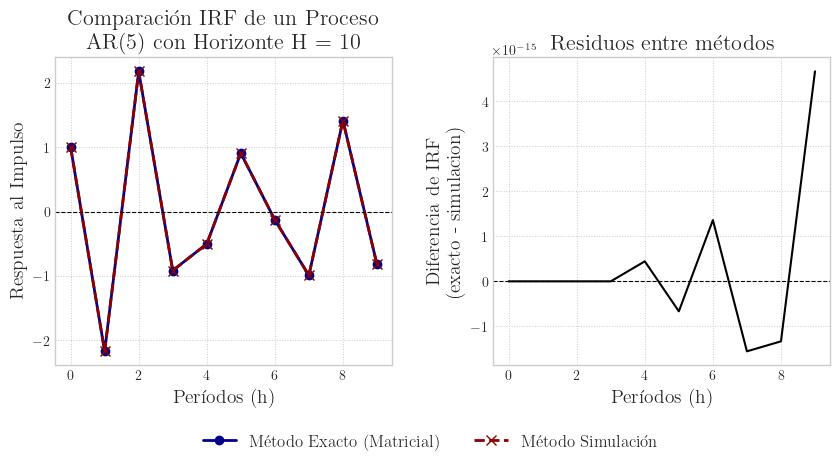

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'wspace':0.3})
axes = plot_irf_comparison(irf_exact, irf_simulation, model=ar_model, ax=axes)
save_figure(fig, path='./presentation/figures/p1/simvsexact.pdf')